<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/unsupervised/clustering/experiment_clustering_kmeans_dbscan_comparison_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# CLUSTERING (UNSUPERVISED LEARNING)
# ============================================

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score
from sklearn.datasets import make_blobs
import numpy as np

# Generate some sample data for demonstration
X, y = make_blobs(n_samples=300, centers=3, random_state=42)

# -------------------------------
# 1. Models
# -------------------------------
clustering_models = {
    "KMeans": KMeans(n_clusters=3, random_state=42, n_init=10),
    "DBSCAN": DBSCAN(eps=0.5)
}

# -------------------------------
# 2. Train + Evaluate
# -------------------------------
cluster_results = {}

for name, model in clustering_models.items():

    # DBSCAN might return -1 for noise points, KMeans expects positive labels
    # For evaluation with adjusted_rand_score, it's often useful to filter out noise or handle it.
    # For this example, we will proceed, but note that DBSCAN's -1 can affect ARI interpretation
    # if not handled specifically (e.g., by treating noise as its own cluster or excluding it).
    labels = model.fit_predict(X)

    # Compare with true labels (evaluation trick)
    # Ensure KMeans n_clusters matches actual centers for meaningful ARI
    score = adjusted_rand_score(y, labels)

    cluster_results[name] = score

    print(f"{name} Score (ARI): {score:.4f}")


KMeans Score (ARI): 1.0000
DBSCAN Score (ARI): 0.6771


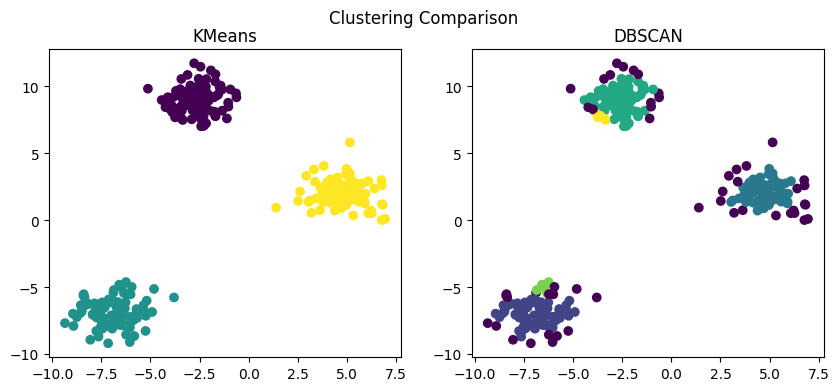

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

for i, (name, model) in enumerate(clustering_models.items()):
    labels = model.fit_predict(X)

    plt.subplot(1,2,i+1)
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
    plt.title(name)

plt.suptitle("Clustering Comparison")
plt.show()

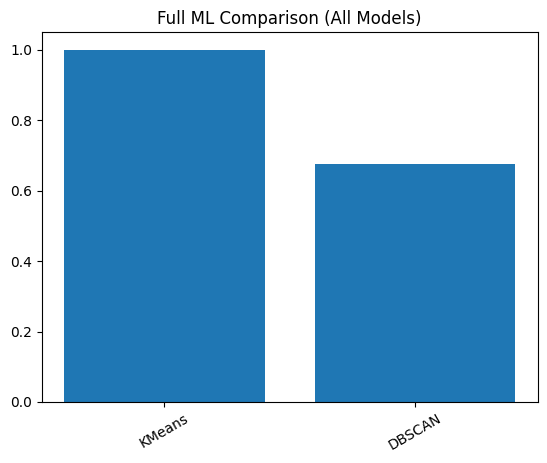

In [ ]:
# Combine supervised + unsupervised results

# Initialize results if not defined, assuming it would contain supervised learning results
if 'results' not in locals() and 'results' not in globals():
    results = {}

all_names = list(results.keys()) + list(cluster_results.keys())
all_scores = list(results.values()) + list(cluster_results.values())

plt.figure()
plt.bar(all_names, all_scores)
plt.title("Full ML Comparison (All Models)")
plt.xticks(rotation=30)
plt.show()